In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn import tree

In [2]:
data = pd.read_csv("gld_price_data.csv")

In [3]:
data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [6]:
data.shape

(2290, 6)

In [7]:
data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [8]:
data.duplicated().sum()

0

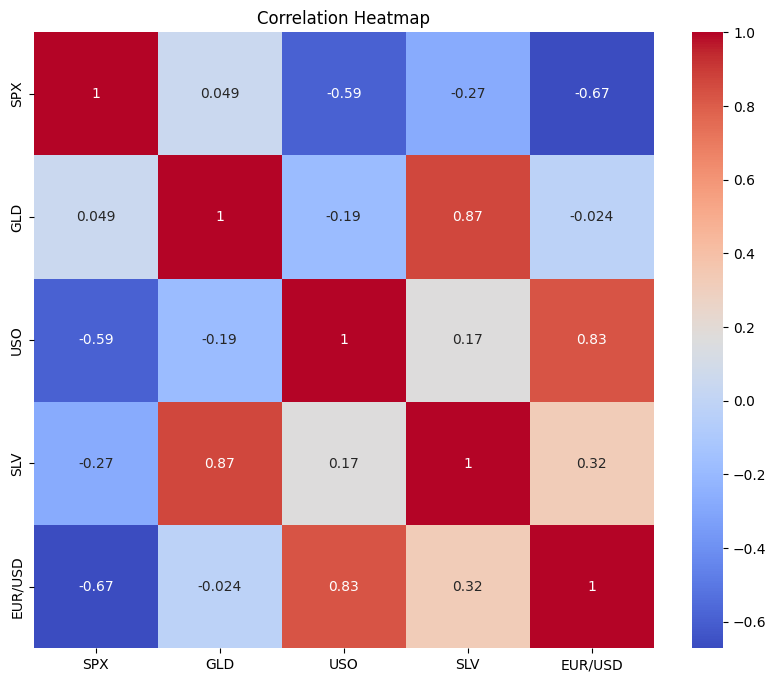

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

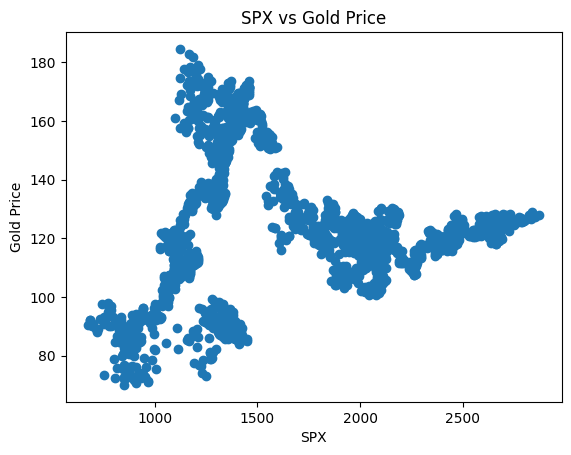

In [10]:
plt.scatter(data['SPX'], data['GLD'])

plt.xlabel("SPX")

plt.ylabel("Gold Price")

plt.title("SPX vs Gold Price")

plt.show()

In [11]:
X = data.drop(['Date', 'GLD'], axis=1)

y = data['GLD']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
depths = range(1, 21)

scores = []

for d in depths:

    model = DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    scores.append(score)

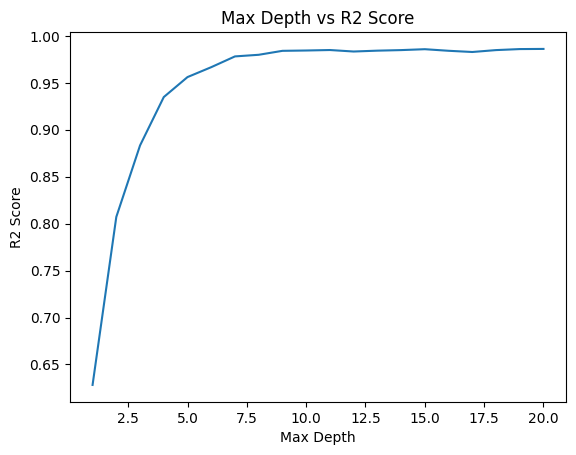

In [14]:
plt.plot(depths, scores)

plt.xlabel("Max Depth")

plt.ylabel("R2 Score")

plt.title("Max Depth vs R2 Score")

plt.show()

In [15]:
best_depth = depths[np.argmax(scores)]

print("Best Max Depth:", best_depth)

Best Max Depth: 20


In [16]:
model = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=20, random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 7.59572472389211
R2 Score: 0.9861467697077169


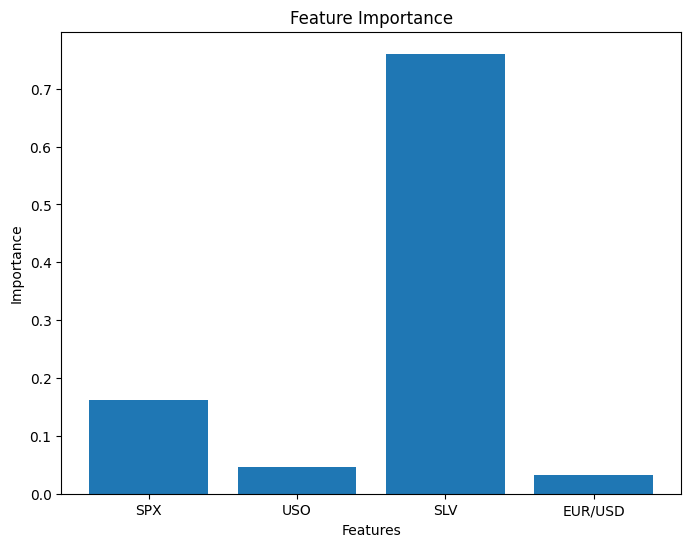

In [19]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,6))

plt.bar(features, importance)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

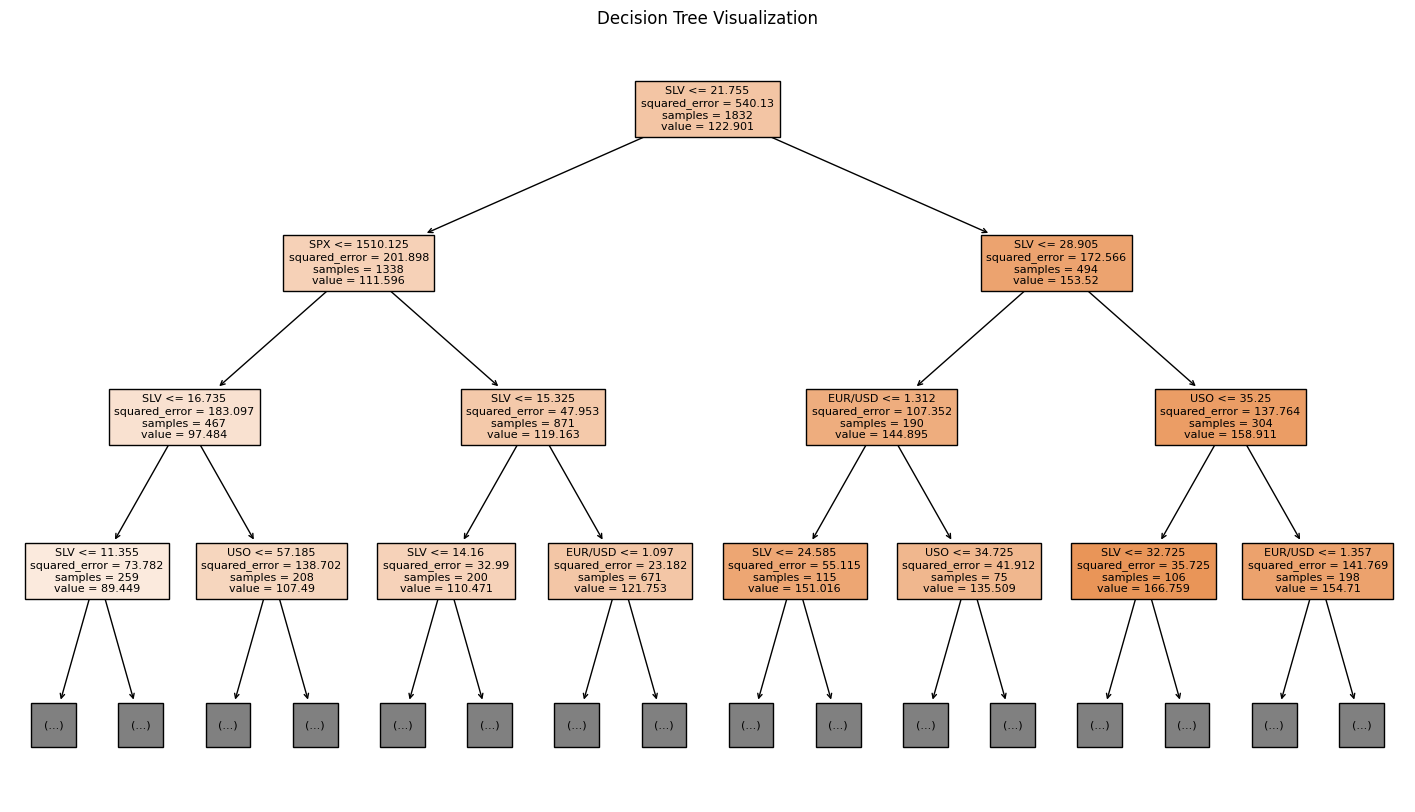

In [22]:
plt.figure(figsize=(18,10))

tree.plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

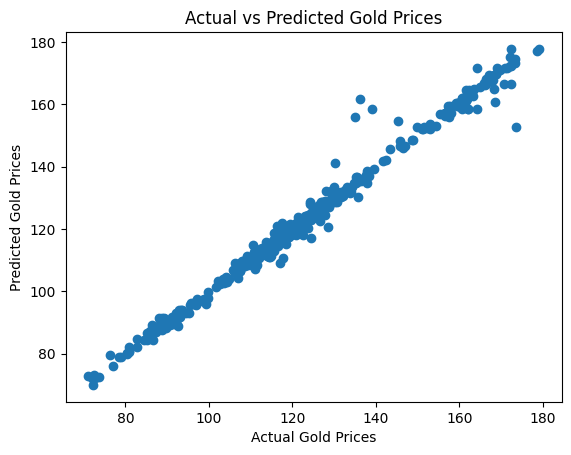

In [23]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Gold Prices")

plt.ylabel("Predicted Gold Prices")

plt.title("Actual vs Predicted Gold Prices")

plt.show()